# Working with Spatial-Temporal Data: Spatial-Temporal Data Processing

Spatial data is data that is related to the dimension of space (from Latin *spatium*), while temporal data is data that is related to the dimension of time (from Latin *tempus*). So spatial-temporal data is data that is related to both time and space.

In this unit, we will investigate concepts and methods related to working with spatial-temporal data, using Galápagos tortoise migration as a case study.

## Setup and Data

First, we import the libraries we will need. In particular, we will be using `geopandas` and `scikit-mobility` (abbreviated as `skmob`) to handle the spatial aspects of the data.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import skmob
from skmob.preprocessing import detection, clustering

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)
import warnings
warnings.simplefilter("ignore")

The original data on tortoise migration comes from the Movebank Data Repository and can be found at https://www.datarepository.movebank.org/handle/10255/move.834. We read the data into a dataframe named `events`.

In [2]:
events = pd.read_csv("Galapagos Tortoise Movement Ecology Programme_2009-2018.csv",sep=',')

When we take a look at the shape of the data, we notice that it has 1.8 million rows:

In [3]:
events.shape

(1841253, 24)

We can also see what the raw data looks like by looking at the first few rows:

In [4]:
events.head()

,event-id,visible,timestamp,location-long,location-lat,eobs:battery-voltage,eobs:fix-battery-voltage,eobs:horizontal-accuracy-estimate,eobs:key-bin-checksum,eobs:speed-accuracy-estimate,eobs:start-timestamp,eobs:status,eobs:temperature,eobs:type-of-fix,eobs:used-time-to-get-fix,ground-speed,heading,height-above-ellipsoid,manually-marked-outlier,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name
0,33691529,True,2010-09-23 16:00:00.000,NaN,NaN,3686,3598,NaN,2636949985,NaN,2010-09-23 16:00:00.000,D,17,0,150,NaN,NaN,NaN,NaN,gps,Chelonoidis,1392,Sparkey,Galapagos Tortoise Movement Ecology Programme
1,33691530,True,2010-09-23 17:00:49.998,-91.103888,-0.456140,3696,3623,3.07,4135080321,2.32,2010-09-23 17:00:00.000,A,17,3,49,0.17,16.38,1033.3,NaN,gps,Chelonoidis,1392,Sparkey,Galapagos Tortoise Movement Ecology Programme
2,33691531,True,2010-09-23 18:00:32.000,-91.103888,-0.456140,3702,3635,3.84,3798461165,2.57,2010-09-23 18:00:01.000,A,19,3,31,0.33,3.28,1035.9,NaN,gps,Chelonoidis,1392,Sparkey,Galapagos Tortoise Movement Ecology Programme
3,33691532,True,2010-09-23 19:00:29.000,-91.103904,-0.456151,3710,3642,3.84,3942563785,2.56,2010-09-23 19:00:00.000,A,22,3,29,0.12,19.66,1034.9,NaN,gps,Chelonoidis,1392,Sparkey,Galapagos Tortoise Movement Ecology Programme
4,33691533,True,2010-09-23 20:00:55.999,-91.103904,-0.456153,3710,3635,3.07,683273842,2.28,2010-09-23 19:59:59.000,A,22,3,56,0.19,6.55,1038.5,NaN,gps,Chelonoidis,1392,Sparkey,Galapagos Tortoise Movement Ecology Programme


Notice how some of the longitude and latitude values are listed as `NaN`.

Next, we examine the data type for the column `timestamp`.

In [5]:
type(events.timestamp[1])

str

Although it is of type `str` (string), we want to parse it as type `datetime`. This can be done using the `parse_date` parameter to the `read_csv()` function.

In [6]:
events = pd.read_csv("Galapagos Tortoise Movement Ecology Programme_2009-2018.csv", sep=',', parse_dates=[2])

In [7]:
type(events.timestamp[1])

pandas._libs.tslibs.timestamps.Timestamp

We can use the `info()` function to learn more about the column names and types. We see that there are 24 columns. The column names give us an idea of what sort of data they contain, but we can look at the [README file](https://datarepository.movebank.org/bitstreams/e398baaf-144e-4548-9584-5f8470685f0c/download) provided by the Movebank Data Repository for more information about the column semantics. 

In [8]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1841253 entries, 0 to 1841252
Data columns (total 24 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   event-id                           int64         
 1   visible                            bool          
 2   timestamp                          datetime64[ns]
 3   location-long                      float64       
 4   location-lat                       float64       
 5   eobs:battery-voltage               int64         
 6   eobs:fix-battery-voltage           int64         
 7   eobs:horizontal-accuracy-estimate  float64       
 8   eobs:key-bin-checksum              int64         
 9   eobs:speed-accuracy-estimate       float64       
 10  eobs:start-timestamp               object        
 11  eobs:status                        object        
 12  eobs:temperature                   int64         
 13  eobs:type-of-fix                   int64         
 14  eo

For consistency, we change the column names to replace "-" and ":" with "_" (using `pd.Series.str.replace()` to make the replacements and `pd.DataFrame.set_axis()` to update the column names). We call this new version of the dataframe `tortoise`. Inspecting the dataframe shows that our changes to the column names were successful.

In [9]:
new_cols = pd.Series(events.columns.values).str.replace(pat = r"[-:]", repl="_", regex=True)
tortoise = events.set_axis(labels = new_cols, axis =1, copy = True).assign()
tortoise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1841253 entries, 0 to 1841252
Data columns (total 24 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   event_id                           int64         
 1   visible                            bool          
 2   timestamp                          datetime64[ns]
 3   location_long                      float64       
 4   location_lat                       float64       
 5   eobs_battery_voltage               int64         
 6   eobs_fix_battery_voltage           int64         
 7   eobs_horizontal_accuracy_estimate  float64       
 8   eobs_key_bin_checksum              int64         
 9   eobs_speed_accuracy_estimate       float64       
 10  eobs_start_timestamp               object        
 11  eobs_status                        object        
 12  eobs_temperature                   int64         
 13  eobs_type_of_fix                   int64         
 14  eo

## Cleaning the Dataset

Next, we take a look at the number of unique elements in each column using the `nunique()` function. By default, this function does not include NA values in its counts.

In [10]:
tortoise.nunique()

event_id                             1841253
visible                                    2
timestamp                            1567017
location_long                         881115
location_lat                          852446
eobs_battery_voltage                     483
eobs_fix_battery_voltage                 890
eobs_horizontal_accuracy_estimate        377
eobs_key_bin_checksum                1840713
eobs_speed_accuracy_estimate            2661
eobs_start_timestamp                  366452
eobs_status                                3
eobs_temperature                          74
eobs_type_of_fix                           2
eobs_used_time_to_get_fix               1042
ground_speed                            1882
heading                                  550
height_above_ellipsoid                 13208
manually_marked_outlier                    1
sensor_type                                1
individual_taxon_canonical_name            4
tag_local_identifier                      89
individual

Take a look at the `location_long` and `location_lat` columns, which contain the longitude and latitude, respectively. Even though there are 1.8 million events, it appears that there are only 800k unique values for longitude and latitude. Could this be because of NA values? (Recall that we saw `NaN` values in these columns earlier.) We can use `pd.DataFrame.notna()`, which counts the number of values that are not NA, to find out whether this is the case.

In [11]:
tortoise.notna().sum()

event_id                             1841253
visible                              1841253
timestamp                            1841253
location_long                        1796385
location_lat                         1796385
eobs_battery_voltage                 1841253
eobs_fix_battery_voltage             1841253
eobs_horizontal_accuracy_estimate    1796385
eobs_key_bin_checksum                1841253
eobs_speed_accuracy_estimate         1796385
eobs_start_timestamp                 1841253
eobs_status                          1841253
eobs_temperature                     1841253
eobs_type_of_fix                     1841253
eobs_used_time_to_get_fix            1841253
ground_speed                         1796385
heading                              1796385
height_above_ellipsoid               1796385
manually_marked_outlier                  494
sensor_type                          1841253
individual_taxon_canonical_name      1841253
tag_local_identifier                 1841253
individual

Notice that `manually_marked_outlier` has 494 values that are not NA. According to the [README](https://datarepository.movebank.org/bitstreams/e398baaf-144e-4548-9584-5f8470685f0c/download), `True` values in this column indicate events marked by human examiners as outliers. We can use the `value_counts()` function to check if all 494 of these values are `True`.

In [12]:
tortoise['manually_marked_outlier'].value_counts(dropna=False)

manually_marked_outlier
NaN     1840759
True        494
Name: count, dtype: int64

Having confirmed that all 494 of these values are `True`, we can drop these events to remove these manually marked outliers. We create a mask using `notna()` to identify the indices we want to remove, and then we drop those indices in place using the `drop()` function.

In [13]:
mask = tortoise["manually_marked_outlier"].notna()
tortoise.drop(index = tortoise.index[mask], inplace = True)

Now that the column `manually_marked_outlier` is no longer relevant for our purposes, we can drop it in place:

In [14]:
tortoise.drop(columns =["manually_marked_outlier"], inplace=True)

Let's take a look at the number of NA values remaining in each column:

In [15]:
tortoise.isna().sum()

event_id                                 0
visible                                  0
timestamp                                0
location_long                        44867
location_lat                         44867
eobs_battery_voltage                     0
eobs_fix_battery_voltage                 0
eobs_horizontal_accuracy_estimate    44867
eobs_key_bin_checksum                    0
eobs_speed_accuracy_estimate         44867
eobs_start_timestamp                     0
eobs_status                              0
eobs_temperature                         0
eobs_type_of_fix                         0
eobs_used_time_to_get_fix                0
ground_speed                         44867
heading                              44867
height_above_ellipsoid               44867
sensor_type                              0
individual_taxon_canonical_name          0
tag_local_identifier                     0
individual_local_identifier              0
study_name                               0
dtype: int6

Notice that all of the columns related to observation measures have the same number of NA values. Could these NA values be for the same events? To find out whether the NAs on different columns happen on the same set of rows, we first find the subset of columns with NA values. We then use `isna.all()` to find out how many rows have NA values in all of these columns.

In [16]:
na_cols = tortoise.columns[tortoise.isna().sum() > 0]
tortoise[na_cols].isna().all(axis=1).sum()

np.int64(44867)

Since this is the same number as the one we observed above, we conclude that these NA values are for the same events.

Since we're mainly interested in the events that have valid geolocations, we can drop the rows with NA values by using `dropna()`:

In [17]:
tortoise.dropna(how='any', inplace=True)

We check the results of this operation by examining the number of NA values in each column again.

In [18]:
tortoise.isna().sum()

event_id                             0
visible                              0
timestamp                            0
location_long                        0
location_lat                         0
eobs_battery_voltage                 0
eobs_fix_battery_voltage             0
eobs_horizontal_accuracy_estimate    0
eobs_key_bin_checksum                0
eobs_speed_accuracy_estimate         0
eobs_start_timestamp                 0
eobs_status                          0
eobs_temperature                     0
eobs_type_of_fix                     0
eobs_used_time_to_get_fix            0
ground_speed                         0
heading                              0
height_above_ellipsoid               0
sensor_type                          0
individual_taxon_canonical_name      0
tag_local_identifier                 0
individual_local_identifier          0
study_name                           0
dtype: int64

This confirms that there are no NA values left in the dataset now.

## Adding and Removing Features

Next, we consider which columns of the dataset will be useful for our purposes. We define a list of these columns and name it `cols`. We then drop all other columns, keeping only our chosen subset.

In [19]:
cols = ['event_id', 'timestamp', 'location_long', 'location_lat',
       'eobs_temperature', 'ground_speed', 'heading', 'height_above_ellipsoid',
       'individual_taxon_canonical_name', 'tag_local_identifier',
       'individual_local_identifier']

tortoise.drop(columns=tortoise.columns.difference(cols), inplace=True)

In addition to dropping unneeded columns, we can also create several new columns to improve our ability to work with the timestamp information. These columns represent different parts of the timestamp such as the year, month, and day.

In [20]:
tortoise['year'] = tortoise["timestamp"].dt.year
tortoise['month'] = tortoise["timestamp"].dt.month
tortoise['date'] = tortoise["timestamp"].dt.date
tortoise['day'] = tortoise["timestamp"].dt.day
tortoise['hour'] = tortoise["timestamp"].dt.hour
tortoise['weekday'] = tortoise["timestamp"].dt.weekday
tortoise['year_month'] = tortoise["timestamp"].apply(lambda t: t.strftime("%Y-%m"))
tortoise['year_week'] = tortoise["timestamp"].apply(lambda t: t.strftime("%Y-%W")) 

## Examining the Dataset

Having cleaned the dataset and decided which columns are relevant, we can begin our examination of the data.

### General Examination

First, we use the `describe()` function to summarize some key statistical aspects of our dataset.

In [21]:
tortoise.describe()

,event_id,timestamp,location_long,location_lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,tag_local_identifier,year,month,day,hour,weekday
count,1.795892e+06,1795892,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06,1.795892e+06
mean,1.342114e+09,2013-10-04 02:38:24.815790848,-9.044068e+01,-7.028889e-01,1.848886e+01,2.712565e-01,1.543643e+02,3.259310e+02,1.798036e+03,2.013243e+03,6.691388e+00,1.571469e+01,1.372403e+01,3.001456e+00
min,3.369138e+07,2009-04-29 16:00:50,-9.118597e+01,-1.385838e+00,-1.200000e+01,0.000000e+00,0.000000e+00,-2.847200e+03,7.650000e+02,2.009000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.754146e+07,2011-07-09 21:00:50.000749824,-9.046015e+01,-7.004788e-01,1.300000e+01,8.000000e-02,7.860000e+00,1.210000e+02,1.380000e+03,2.011000e+03,4.000000e+00,8.000000e+00,1.100000e+01,1.000000e+00
50%,2.683602e+08,2013-10-16 23:00:45.000499968,-9.041491e+01,-6.607453e-01,1.800000e+01,1.600000e-01,6.554000e+01,1.698000e+02,1.394000e+03,2.013000e+03,7.000000e+00,1.600000e+01,1.500000e+01,3.000000e+00
75%,1.748313e+09,2015-11-23 00:00:12.499500032,-9.024347e+01,-6.311809e-01,2.400000e+01,2.900000e-01,3.362000e+02,3.517000e+02,1.410000e+03,2.015000e+03,1.000000e+01,2.300000e+01,1.900000e+01,5.000000e+00
max,7.674895e+09,2018-10-10 15:45:10,-8.965603e+01,-3.619578e-01,6.300000e+01,4.752100e+02,3.597900e+02,1.690220e+04,5.275000e+03,2.018000e+03,1.200000e+01,3.100000e+01,2.300000e+01,6.000000e+00
std,2.106486e+09,NaN,4.207012e-01,2.626618e-01,7.924963e+00,1.803277e+00,1.531188e+02,3.226248e+02,1.114890e+03,2.670879e+00,3.372154e+00,8.801041e+00,6.915334e+00,1.999368e+00


Let's take a closer look at some of these columns.

In [21]:
tortoise[["timestamp", "location_long", "location_lat", "eobs_temperature", "ground_speed", "heading", "height_above_ellipsoid"]].head(10)

,timestamp,location_long,location_lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid
1,2010-09-23 17:00:49.998,-91.103888,-0.456140,17,0.17,16.38,1033.3
2,2010-09-23 18:00:32.000,-91.103888,-0.456140,19,0.33,3.28,1035.9
3,2010-09-23 19:00:29.000,-91.103904,-0.456151,22,0.12,19.66,1034.9
4,2010-09-23 20:00:55.999,-91.103904,-0.456153,22,0.19,6.55,1038.5
5,2010-09-23 21:00:15.001,-91.103918,-0.456149,22,0.21,13.76,1032.5
6,2010-09-23 22:00:43.999,-91.103925,-0.456123,22,0.10,7.86,1028.3
7,2010-09-23 23:00:25.999,-91.103951,-0.456125,18,0.21,133.04,1024.7
8,2010-09-24 00:00:19.998,-91.104032,-0.456170,15,0.11,8.52,1016.2
9,2010-09-24 01:00:56.998,-91.103877,-0.456109,11,0.20,343.41,1035.4
10,2010-09-24 11:00:50.998,-91.104021,-0.456098,5,0.10,342.75,1024.2


### Identifiers

The column `individual_taxon_canonical_name` keeps track of which taxon each tortoise belongs to, while the column `individual_local_identifier` identifies each individual turtle. Using aggregation, we can count how many events are associated with each tortoise of each taxon.

In [23]:
temp_df = tortoise.groupby(["individual_taxon_canonical_name","individual_local_identifier"]).agg(events_count = ("event_id", "count"))
temp_df.sort_values(by="events_count", ascending=False).head(100)

events_count
individual_taxon_canonical_name individual_local_identifier              
Chelonoidis porteri             Gnasher                             86050
                                Valencia                            84075
                                Sebastian                           51320
                                Carolina                            45420
Chelonoidis donfaustoi          Wilman                              44501
Chelonoidis                     Christian                           42509
                                Sparkey                             42406
                                Martin                              41965
Chelonoidis porteri             Steve Devine                        41803
Chelonoidis                     Anne                                41110
Chelonoidis donfaustoi          Alison                              40003
                                Kitty                               39955
                                Herbert                             39715
                                Sandra                              39595
                                Karla                               39253
                                Marilyn                             39232
Chelonoidis porteri             Iggy                                39161
Chelonoidis                     Greg                                38789
Chelonoidis porteri             Lolo                                38700
Chelonoidis                     Franz                               36409
Chelonoidis donfaustoi          Helber                              34646
                                Nigrita                             34273
Chelonoidis                     Jeneene                             31886
Chelonoidis porteri             Lore                                31494
Chelonoidis hoodensis           Zelfa                               30973
                                Nathalie                            30714
Chelonoidis donfaustoi          Connor                              30607
Chelonoidis                     Franz' girlie                       30185
Chelonoidis porteri             Lucy                                30034
Chelonoidis                     Birgit                              28314
                                Isabela                             28214
                                Spikey                              26750
Chelonoidis hoodensis           Emma Espanola                       25545
Chelonoidis porteri             Chrissie                            25350
                                Sepp                                23711
Chelonoidis hoodensis           Skandar's Girlfriend                20507
Chelonoidis donfaustoi          Narcissa                            20360
Chelonoidis porteri             Veronica                            20032
Chelonoidis donfaustoi          Samy                                19207
Chelonoidis porteri             Sir David                           18557
                                Yvonne                              18333
                                Mandy                               18328
Chelonoidis donfaustoi          Maria                               18114
Chelonoidis hoodensis           Randal                              17604
Chelonoidis porteri             Delmira                             17416
Chelonoidis donfaustoi          Melina                              16526
                                Fredy                               15281
Chelonoidis porteri             Karlitos                            14359
                                Wacho                               13392
Chelonoidis hoodensis           Miriam                              13091
                                Skandar                             13078
                                Walter                              13001
Chelonoidis donfaustoi          Jumbo                            

Take a look at the dataframe above and examine what is special about it. What is the same as the original dataframe, and what has been changed? (Hint: look at the column names.)

The column `tag_local_identifier` contains the tag ID for each event, while `individual_local_identifier` contains each tortoise's unique name. However, if we take a closer look at `tag_local_identifier`, we notice that some of the tags were reused on different tortoises over time.

In [38]:
df1 = tortoise.groupby(["tag_local_identifier"]).agg(cnt = ("individual_local_identifier", "nunique",)).reset_index()
df1[df1.cnt>1]

,tag_local_identifier,cnt
14,1378,2
21,1385,2
23,1387,2
32,1396,2
34,1398,2
37,1401,2
42,1406,2
43,1407,3
48,3133,2
61,3148,2


For example, tag 1378 was used for both Yvonne and Skandar:

In [41]:
tortoise[tortoise['tag_local_identifier'] == 1378]['individual_local_identifier'].value_counts()

individual_local_identifier
Yvonne     18333
Skandar    13078
Name: count, dtype: int64

Since some tags were used for more than one tortoise, we will need to use the tortoises' names in `individual_local_identifier` for unique identifiers.

If we consider the reverse situation — where the same tortoise uses more than one tag — we find that there are several tortoises that have been assigned two different tags. Who are these tortoises, and what should we know about the reuse of tags?

In [28]:
df1 = tortoise.groupby(["individual_local_identifier"]).agg(cnt = ("tag_local_identifier", "nunique",)).reset_index()
df1[df1.cnt>1]

,individual_local_identifier,cnt
51,Mandy,2
62,Nigrita,2
68,Samuel,2
70,Sandra,2
71,Sebastian,2


The most likely scenario is that the GPS devices were reused. But how can we be sure? Can we find any gaps between when the devices were switched? Consider how you would find out if there were any gaps in data collection for these tortoises. (Hint: only Mandy did not have an obvious gap.)

### Individual Tortoises

Now that we have determined which column to use as a unique identifier, let's take a look at some specific tortoises to get an idea of what their migration patterns look like. There are four different taxa:

In [33]:
tortoise['individual_taxon_canonical_name'].unique()

array(['Chelonoidis', 'Chelonoidis porteri', 'Chelonoidis hoodensis',
       'Chelonoidis donfaustoi'], dtype=object)

Here are some tortoises we may want to study for each taxon:
 - Chelonoidis porteri	— The western Santa Cruz tortoise is a subspecies of Galápagos tortoise endemic to Santa Cruz Island in the Galápagos. They are found only on the southwestern slopes of the island, with an estimated range of 141 sq. kilometers. 
   - Steve Devine
   - Carolina — born in 1930?
   - Gnasher
 - Chelonoidis donfaustoi — Chelonoidis niger donfaustoi, known as the eastern Santa Cruz tortoise, is a subspecies of Galápagos tortoise living on Santa Cruz Island, within the Galápagos. Until 2015, C. n. donfaustoi was classified as part of another subspecies, Chelonoidis porteri.
   - Alison
   - Marilyn
   - Kitty
   - Helber
   - Connor
 - Chelonoidis — Chelonoidis is a genus of turtles in the tortoise family erected by Leopold Fitzinger in 1835. They are found in South America and the Galápagos Islands, and formerly had a wide distribution in the West Indies. The multiple subspecies of the Galápagos tortoise are among the largest extant terrestrial chelonians. 
   - Christian — vandenburghi
 - Chelonoidis hoodensis — The Hood Island giant tortoise is a subspecies of Galápagos tortoise endemic to Española Island in the Galápagos.
   - Skandar
   - Skandar's Girlfriend 

We'll start by looking at the *Chelonoidis donfaustoi* tortoise Alison. We create a dataframe called `alison` and then examine the minimum and maximum values.

In [63]:
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]

In [44]:
pd.DataFrame(alison.max().values,alison.min().values)

,0
46119247,7513055046
2010-09-17 17:01:25.998000,2018-10-01 16:00:29.998000
-90.27502,-90.239427
-0.656178,-0.629772
-2,35
0.0,61.1
0.0,359.79
-139.1,630.6
Chelonoidis donfaustoi,Chelonoidis donfaustoi
1402,1402


Even though there are duplicates among latitude and longitude, we should keep them, since they may reveal interesting patterns of movement.

In [47]:
alison[["location_lat", "location_long", "ground_speed"]]

,location_lat,location_long,ground_speed
1290187,-0.635366,-90.241889,0.00
1290188,-0.635563,-90.242230,0.21
1290189,-0.635515,-90.242210,0.15
1290190,-0.635356,-90.242227,0.75
1290191,-0.635276,-90.242101,0.08
...,...,...,...
1332568,-0.635341,-90.243718,0.20
1332569,-0.635348,-90.243748,0.17
1332570,-0.635363,-90.243731,0.25
1332571,-0.635290,-90.243696,2.16


Next, we select all of Alison's longitudinal movements that have a ground speed of less than 1 meter per second and plot them over time:

<Figure size 2000x500 with 0 Axes>

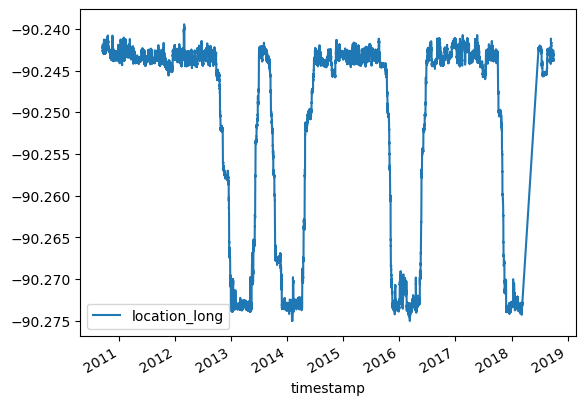

In [62]:
plt.figure(figsize = (20,5))
tmp = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
tmp.plot(x="timestamp", y="location_long");

To get more information, we can use `scatterplot` and color the markers by the ground speed. What do you notice?

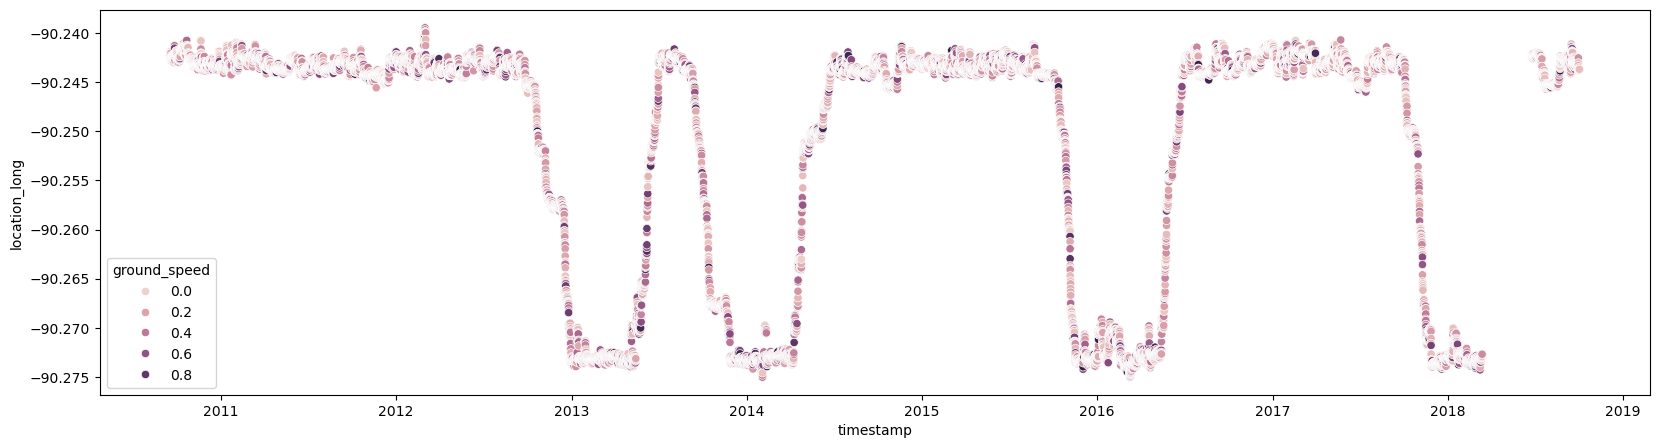

In [61]:
plt.figure(figsize = (20,5))
sns.scatterplot(tmp, x = "timestamp", y="location_long", hue="ground_speed");

Next, let's plot all of Alison's latitudinal movements over time:

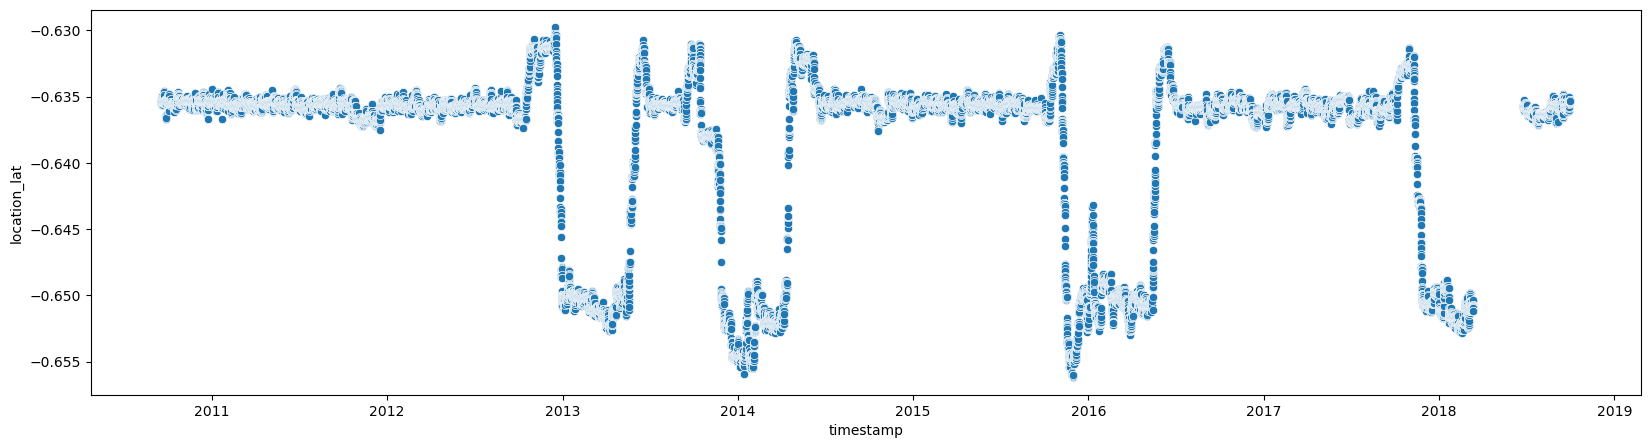

In [67]:
plt.figure(figsize = (20,5))
sns.scatterplot(alison, x = "timestamp", y="location_lat");

Finally, let's plot both latitudinal and longitudinal movement over time for Alison using a scatter plot, coloring the markers by year:

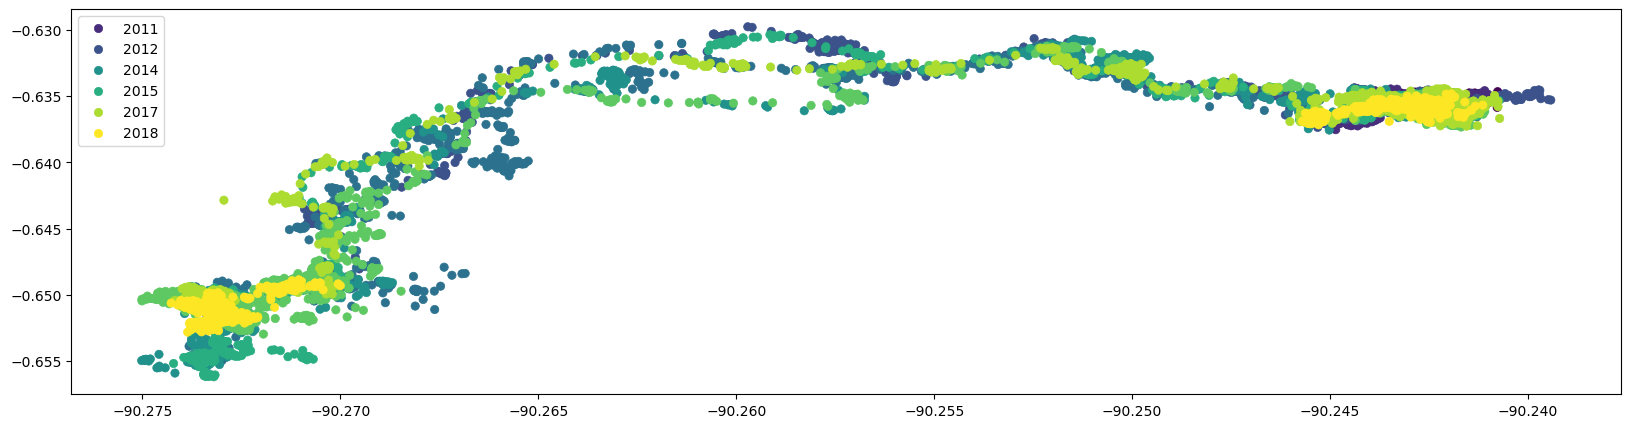

In [94]:
plt.figure(figsize = (20,5))
ax = plt.axes()
sns.set_palette('viridis')
sns.scatterplot(
    x=alison.location_long.values, y=alison.location_lat.values,
    hue=alison.year.values, edgecolor=None, palette='viridis'
);

We can also visualize Alison's movements over time using a line plot:

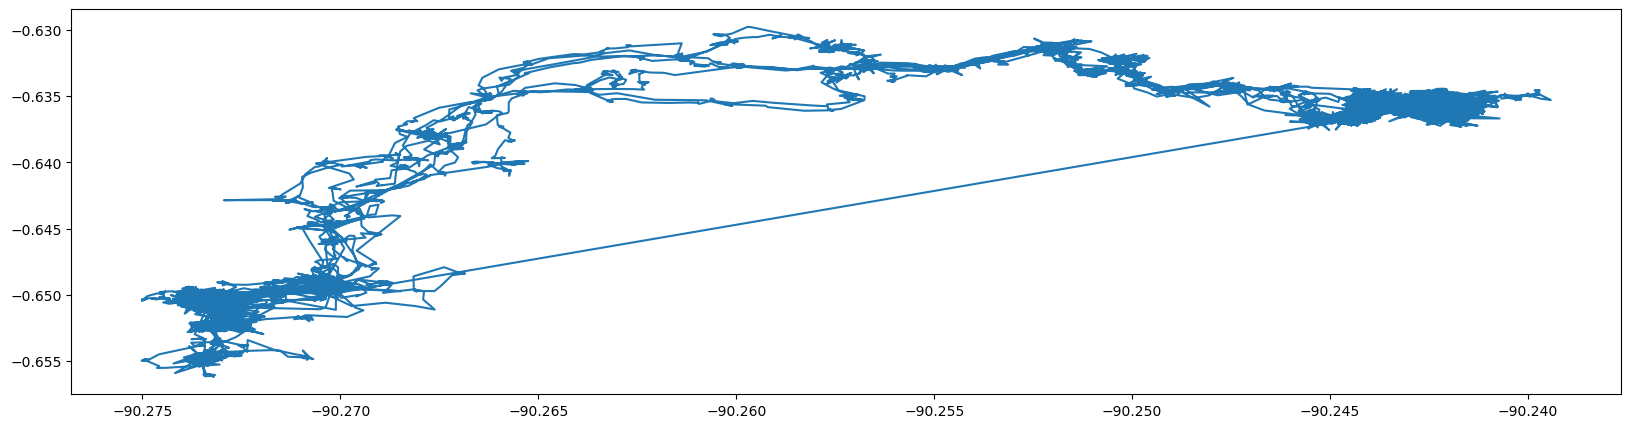

In [79]:
plt.figure(figsize = (20,5))
ax = plt.axes()
ax.plot(alison.location_long.values, alison.location_lat.values);

What do you notice about each plot? How do Alison's movements compare to the research paper's hypotheses that 1) migration timing may differ from year to year and 2) migration route remains consistent across time?

Let's compare our observations for Alison to another tortoise's migration patterns. First, we define a method that will allow us to plot either longitudinal or latitudinal movement over time for any tortoise:

In [69]:
def individual_lat_long(name, lat_long):
    plt.figure(figsize = (20,5))
    df_name = tortoise[tortoise["individual_local_identifier"] == name]
    sns.scatterplot(df_name, x = "timestamp", y=lat_long)


Then we try out our new function on another tortoise named Christian, using longitudinal movement.

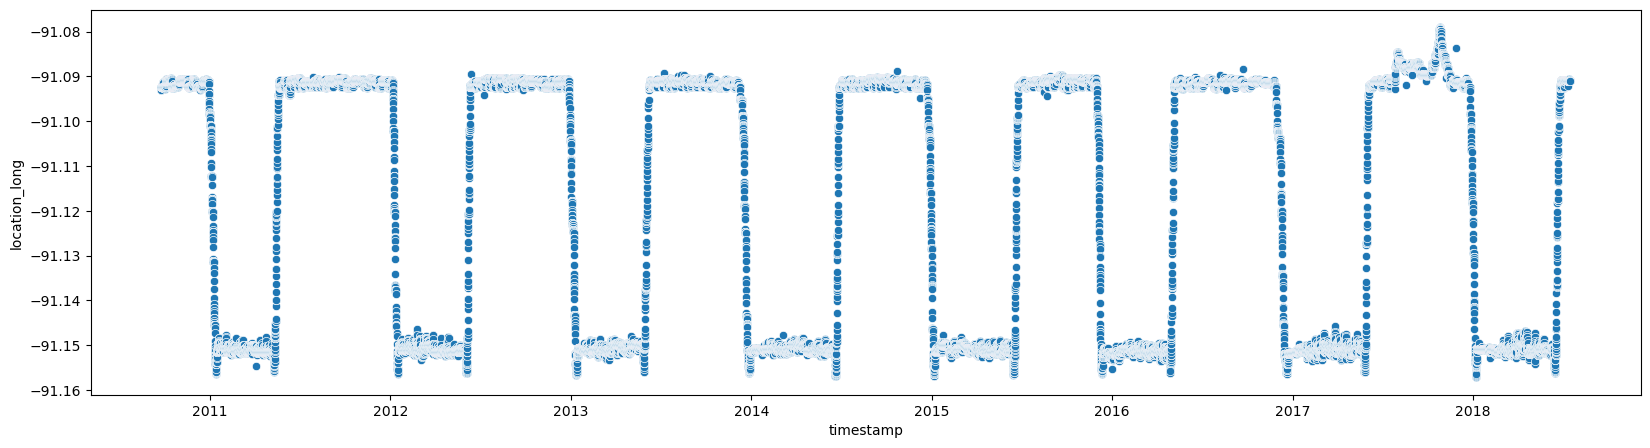

In [70]:
individual_lat_long("Christian", "location_long")

How do Christian's migration patterns compare to Alison's?

The events for Alison and Christian stretch across several years, providing us with valuable insight into the tortoises' migration habits. However, not all of the tortoises in the dataset have data available for such a long period of time. We can use the following code to determine how many days passed between the first and last observations recorded for each tortoise:

In [38]:
temp_df = tortoise.groupby("individual_local_identifier").agg(max_time = ('timestamp', max), min_time = ('timestamp', min) )
temp_df["length"] = (temp_df.max_time - temp_df.min_time)
temp_df.sort_values(by="length")

,max_time,min_time,length
individual_local_identifier,,,
Roby,2016-06-17 16:02:07.000,2016-06-17 15:44:53.000,0 days 00:17:14
Lola,2013-11-26 09:01:00.998,2013-11-02 21:00:14.999,23 days 12:00:45.999000
Toots,2013-12-30 00:00:56.998,2013-11-20 00:00:50.001,40 days 00:00:06.997000
Andres,2017-02-06 13:23:23.000,2016-12-09 00:00:47.000,59 days 13:22:36
Freddy V,2013-11-22 12:00:57.001,2013-08-14 00:00:55.999,100 days 12:00:01.002000
Erbert,2013-11-27 12:00:45.000,2013-08-17 00:00:26.001,102 days 12:00:18.999000
Kiana,2013-12-04 11:45:08.000,2013-07-25 20:00:11.000,131 days 15:44:57
Graciella,2013-12-09 12:00:49.999,2013-07-20 00:00:56.000,142 days 11:59:53.999000
Johnny,2017-01-09 16:00:40.000,2016-08-15 00:00:56.999,147 days 15:59:43.001000


Because the observations for some tortoises span less than a month's or a year's time, our conclusions about these tortoises' migratory patterns may not be as strong as our conclusions about the habits of tortoises for which we have longer stretches of data, like Alison and Christian.